In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from flow import sample_images
# jax is causing memory leaks for me
# from transforms_jax import radon
from transforms import radon
from utils import load_checkpoint
from torchdiffeq import odeint
import time
from torch import optim
from torchmetrics import CatMetric
from unet import Unet

from torch.autograd.functional import hessian


/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
torch.manual_seed(159753)
np.random.seed(159753)

torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)


In [3]:

im_size = 64
problem = "circles"
checkpoint_path = f'problems/{problem}/checkpoints/{im_size}x{im_size}-v2/ckp_7938.tar'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# match the number of channels to your model
model = Unet(ch=32).to(device)

# ema_model = torch.optim.swa_utils.AveragedModel(
#     model, multi_avg_fn=torch.optim.swa_utils.get_ema_multi_avg_fn(0.9999)
# )
_, _, model, _, _, _= load_checkpoint(model=model, path=checkpoint_path)
model.eval()

Unet(
  (input_proj): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResBlock(
        (skip_connection): Identity()
        (block1): Sequential(
          (0): GroupNorm(32, 32, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Identity()
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (block2): Sequential(
          (0): GroupNorm(32, 32, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (cond_block): ConditioningBlock(
          (proj): Sequential(
            (0): SiLU()
            (1): Linear(in_features=128, out_features=64, bias=True)


In [4]:
from typing import Callable, Dict, List, Optional

from torch import autocast
from torchdiffeq import odeint_adjoint 
import torch.nn as nn


def inverse_loss_fn(x, y):
    """
    Loss function for the inverse problem.
    """
    loss = torch.mean((x - y) ** 2)
    return loss


def ode_integrate(ode_func: nn.Module,
                  init_x: torch.Tensor,
                  ode_opts: Dict = {},
                  t_eps: float = 0,
                  init_t: float = 0.,
                  final_t: float = 1.,
                  t_arr: Optional[List[float]] = None,
                  num_steps: int = 5,
                  intermediate_points: bool = False
      ) -> torch.Tensor:

    if t_arr is None:
        t = torch.linspace(init_t - t_eps, final_t, num_steps).to(init_x.device)
    else:
        t = torch.tensor(t_arr, dtype=torch.float32, device=init_x.device)

    ode_opts = {
        "atol": 1e-5, 
        "rtol": 1e-5, 
        "method": "euler", # "dopri5", "rk4", "euler", "adams", "bdf"
        **ode_opts
    }

    z = odeint(
        func = lambda t, x: ode_func(x, t.expand(x.shape[0])),
        y0 = init_x,
        t = t,
        **ode_opts
    )

    if not intermediate_points:
        return z[-1]
    return z


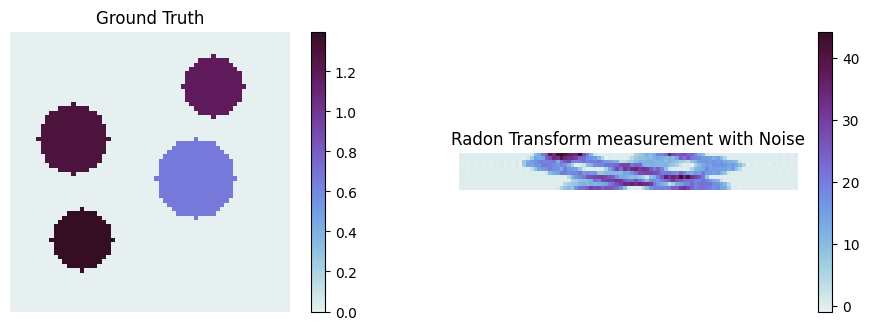

In [5]:
# load data and select a random ground truth from test set
test_data = torch.load(f'data/{problem}-dataset-{im_size}.pt')["test"]
idx = np.random.randint(0, len(test_data))
gt = test_data[idx].to(device).unsqueeze(0)
N=10
# apply radon transform, and apply multiplicative noise
img_radon = radon.radon_transform(gt.squeeze().cpu().numpy(), N=N)
img_radon = torch.tensor(img_radon, device=device, dtype=torch.float32).unsqueeze(0)
img_radon = img_radon.unsqueeze(0)  # add batch dimension   

# mult noise
img_radon = (1 + 0.1 * torch.randn_like(img_radon)) * img_radon
# plot gt, plot img_radon, plot initial guess in x_0 space, and plot flow realization
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(gt.squeeze().cpu().numpy(), cmap=cmocean.cm.dense)
plt.title('Ground Truth')
plt.axis('off')
plt.colorbar()
plt.subplot(2, 2, 2)
plt.imshow(img_radon.squeeze().cpu().numpy(), cmap=cmocean.cm.dense)
plt.title('Radon Transform measurement with Noise')
plt.axis('off')
plt.colorbar()

In [6]:
# getting normalization constants
train_min, train_max = torch.min(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"]), torch.max(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"])

In [7]:
max_iter = 20
optim_steps = 1000
target_cost = .05
time_limit = 500
lr = 0.3
x1_trajectory = []
init_x = torch.randn((1, 1, im_size, im_size), device=device, dtype=torch.float32)
init_x.requires_grad = True
y = img_radon
# history_size depends on your VRAM.
optimizer = optim.LBFGS([init_x], max_iter=max_iter, lr=lr, line_search_fn='strong_wolfe', history_size=20)
# or we can try sgd
# optimizer = torch.optim.SGD([init_x], lr=lr, nesterov=True, momentum=0.9)
# optimizer = optim.Adam([init_x], lr=lr, betas=(0.9, 0.99), eps=1e-8, weight_decay=0.01)

svd_traj = []

metrics = {'loss': CatMetric(), 
           'cost': CatMetric(), 
           'reg': CatMetric(),
           'norm_x0': CatMetric(), 
           'std_x0': CatMetric(), 
           'mean_x0': CatMetric(), 
           'time': CatMetric()
           }
start_time = time.time()
# add metrics to tqdm
for step in range(optim_steps):
    print(f"step: {step}")
    def closure():
        global loss
        global x1
        optimizer.zero_grad()

        reg_loss = torch.tensor(0.).to(init_x)

        ### solve for x1
        x1 = ode_integrate(ode_func=model, init_x =init_x, num_steps=5)
        # unnormalize x1
        x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
        
        # degraded_x1 = H(x1)
        degraded_x1 = radon.radon_transform(x1, N=N)
        cost = inverse_loss_fn(degraded_x1, y)
        loss = cost 

        norm_x0 = init_x.norm()
        std_x0 = init_x.std()
        mean_x0 = init_x.mean()

        metrics['norm_x0'].update(norm_x0.item())
        metrics['std_x0'].update(std_x0.item())
        metrics['mean_x0'].update(mean_x0.item())
        metrics['cost'].update(cost.item())
        metrics['reg'].update(reg_loss.item())
        metrics['loss'].update(loss.item())

        loss.backward()

        with torch.no_grad():
            # compute singular value decay of hess of loss wrt x1
            hess_dim = im_size * im_size
            print("Computing Hessian...")
            hess_x1 = hessian(
                lambda x : inverse_loss_fn(radon.radon_transform(x, N=N), y), 
                inputs=x1,
                vectorize=True,
                )
            hess_x1 = hess_x1.view(hess_dim, hess_dim)

            _, svd_x1, _ = torch.linalg.svd(hess_x1, full_matrices=False)
            svd_traj.append(svd_x1)

        return loss

    optimizer.step(closure)

    x1_trajectory.append(x1.detach().cpu().numpy())

    elapsed = time.time() - start_time
    metrics['time'].update(elapsed)

    elapsed = elapsed/60
    print(f"[Step {step}] Loss {loss.item()}"
        + f"| time: {elapsed} mins")

    if target_cost is not None:
        mets_cost = metrics['cost'].compute()
        if mets_cost.dim() > 0:
            mets_cost = mets_cost[-1]
        last_cost = mets_cost.item()
        if last_cost <= target_cost:
            print(f'reached cost of {last_cost}')
            break

    if time_limit is not None:
        elapsed = (time.time() - start_time)/60 # time in minutes
        if elapsed > time_limit:
            print(f'reached time limit of {time_limit} mins')
            break

with torch.no_grad():
    x1 = ode_integrate(model, init_x)
    x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
x1_trajectory.append(x1.detach().cpu().numpy())



step: 0


Computing Hessian...


Computing Hessian...


Computing Hessian...


Computing Hessian...


...

Computing Hessian...


Computing Hessian...


Computing Hessian...


Computing Hessian...


[Step 1] Loss 1.9552282094955444| time: 737.6979372262955 mins
reached time limit of 500 mins


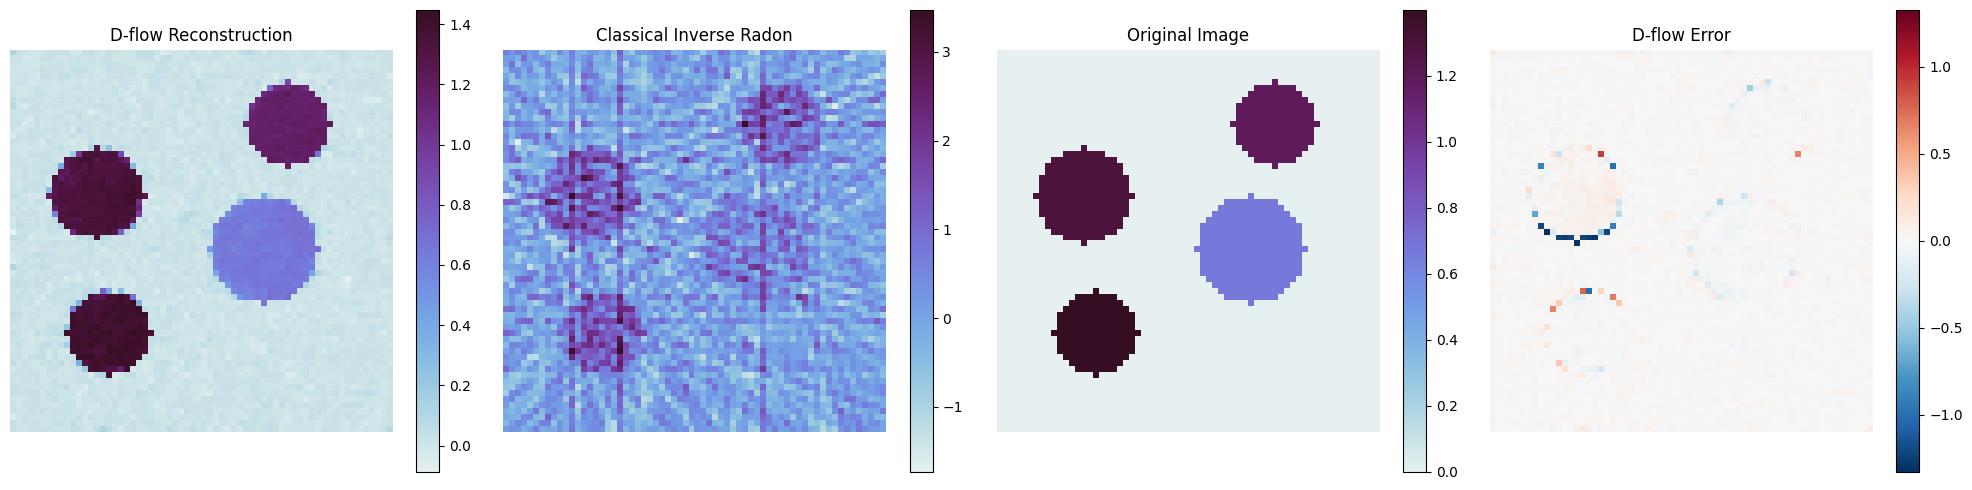

D-flow Results
MSE: 0.006720
MAE: 0.026073
PSNR: 24.65 dB
Rel. L2 Error: 0.1707

Classical Inverse Radon Results
MSE: 0.310384
MAE: 0.439590
PSNR: 8.00 dB
Rel. L2 Error: 1.1603


In [8]:
import warnings

# Suppress warnings from transforms
warnings.filterwarnings('ignore', category=RuntimeWarning)
np.seterr(divide='ignore', invalid='ignore')

# plot error and final result
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Reconstructed image (D-flow)
im1 = axes[0].imshow(x1.squeeze().detach().cpu().numpy(), cmap=cmocean.cm.dense)
axes[0].set_title('D-flow Reconstruction')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

# Classical inverse radon transform
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    classical_recon = radon.iradon_transform(img_radon.squeeze().cpu().numpy())

im2 = axes[1].imshow(classical_recon.real, cmap=cmocean.cm.dense)
axes[1].set_title('Classical Inverse Radon')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

# Original image
im3 = axes[2].imshow(gt.squeeze().cpu().numpy(), cmap=cmocean.cm.dense)
axes[2].set_title('Original Image')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2])

# Error/difference (D-flow vs Original)
error = x1.squeeze().detach().cpu().numpy() - gt.squeeze().cpu().numpy()
im4 = axes[3].imshow(error, cmap='RdBu_r', vmin=-np.abs(error).max(), vmax=np.abs(error).max())
axes[3].set_title('D-flow Error')
axes[3].axis('off')
plt.colorbar(im4, ax=axes[3])

plt.tight_layout()
plt.show()

# Print comparison metrics
mse_dflow = np.mean(error**2)
mae_dflow = np.mean(np.abs(error))
psnr_dflow = 20 * np.log10(np.max(gt.squeeze().cpu().numpy()) / np.sqrt(mse_dflow))

error_classical = classical_recon.real - gt.squeeze().cpu().numpy()
mse_classical = np.mean(error_classical**2)
mae_classical = np.mean(np.abs(error_classical))
psnr_classical = 20 * np.log10(np.max(gt.squeeze().cpu().numpy()) / np.sqrt(mse_classical))

print("D-flow Results")
print(f"MSE: {mse_dflow:.6f}")
print(f"MAE: {mae_dflow:.6f}")
print(f"PSNR: {psnr_dflow:.2f} dB")
print(f"Rel. L2 Error: {np.linalg.norm(error) / np.linalg.norm(gt.squeeze().cpu().numpy()):.4f}")

print("\nClassical Inverse Radon Results")
print(f"MSE: {mse_classical:.6f}")
print(f"MAE: {mae_classical:.6f}")
print(f"PSNR: {psnr_classical:.2f} dB")
print(f"Rel. L2 Error: {np.linalg.norm(error_classical) / np.linalg.norm(gt.squeeze().cpu().numpy()):.4f}")


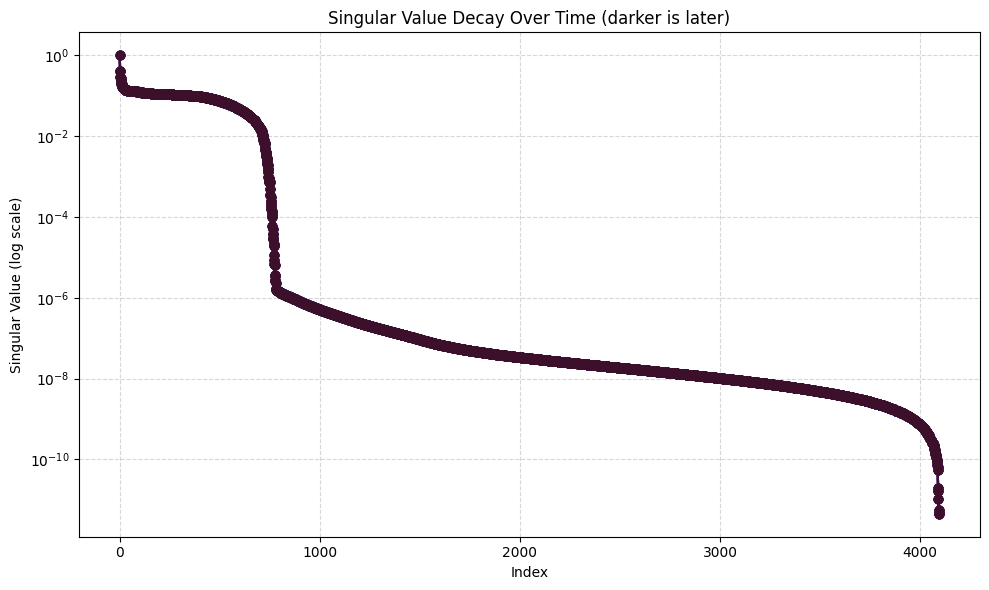

In [9]:
# Plot singular values over time (it's going to be empty if the svd trajectory is commented out)
plt.figure(figsize=(10, 6))
for i, svd in enumerate(svd_traj):
    svd = svd / svd[0]  # normalize by the first singular value
    plt.semilogy(svd[:im_size*im_size].cpu().numpy(), marker='o', linestyle='-', alpha=0.5, label=f'Iteration {i}', color=cmocean.cm.dense(i / len(svd_traj)))
plt.title('Singular Value Decay Over Time (darker is later)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

In [10]:
import matplotlib.animation as animation
from IPython.display import HTML

# Create animation of x1 trajectory
fig, ax = plt.subplots(figsize=(8, 8))

def animate(frame):
    ax.clear()
    img = x1_trajectory[frame].squeeze()
    im = ax.imshow(img, cmap=cmocean.cm.dense, vmin=img.min(), vmax=img.max())
    ax.set_title(f'D-flow Reconstruction - Step {frame}', fontsize=14)
    ax.axis('off')
    return [im]

# Sample every 10th frame to make animation smoother and smaller
frame_indices = list(range(0, len(x1_trajectory), max(1, len(x1_trajectory) // 50)))
if len(frame_indices) > 100:  # Limit to 100 frames max
    frame_indices = frame_indices[::len(frame_indices)//100]

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=frame_indices, 
                             interval=200, blit=False, repeat=True)

plt.close(fig)  # Close the figure to prevent blank canvas display

# Convert to HTML5 video for inline playback
html_anim = HTML(anim.to_jshtml())
html_anim

In [11]:
# Create side-by-side comparison animation
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

gt_img = gt.squeeze().cpu().numpy()

def animate_comparison(frame):
    # Clear all axes
    ax1.clear()
    ax2.clear() 
    ax3.clear()
    
    # Current reconstruction
    current_img = x1_trajectory[frame].squeeze()
    
    # Plot reconstruction
    im1 = ax1.imshow(current_img, cmap=cmocean.cm.dense, vmin=gt_img.min(), vmax=gt_img.max())
    ax1.set_title(f'Reconstruction - Step {frame}', fontsize=12)
    ax1.axis('off')
    
    # Plot ground truth
    im2 = ax2.imshow(gt_img, cmap=cmocean.cm.dense, vmin=gt_img.min(), vmax=gt_img.max())
    ax2.set_title('Ground Truth', fontsize=12)
    ax2.axis('off')
    
    # Plot difference
    diff = current_img - gt_img
    im3 = ax3.imshow(diff, cmap='RdBu_r', vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
    ax3.set_title(f'Difference', fontsize=12)
    ax3.axis('off')
    
    return [im1, im2, im3]

# Use same frame sampling as before
anim_comparison = animation.FuncAnimation(fig, animate_comparison, frames=frame_indices, 
                                        interval=300, blit=False, repeat=True)

plt.close(fig)  # Close the figure to prevent blank canvas display

# Convert to HTML5 video for inline playback
html_comparison = HTML(anim_comparison.to_jshtml())
html_comparison